<a href="https://colab.research.google.com/github/aryan2107-cloud/100-Day-ML-Challenge-/blob/main/Day40_Interpretabilit%26Final_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve)

In [4]:
!pip install shap xgboost lightgbm -q
import shap
import xgboost as xgb
import lightgbm as lgb
shap.initjs()
print('SHAP ready')


SHAP ready


In [9]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
df = pd.read_excel(url, header=1)

target_col = 'default payment next month'
print(f"Dataset: {df.shape[0]:,} loans, {df.shape[1]} features")
print(f"Default rate: {df[target_col].mean():.2%}")

Dataset: 30,000 loans, 25 features
Default rate: 22.12%


In [11]:
x = df.drop(target_col, axis=1)
y = df[target_col]

numeric_cols = x.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = x.select_dtypes(include=['object']).columns.tolist()

x_encoded = x.copy()
for col in categorical_cols:
  x_encoded[col] = LabelEncoder().fit_transform(x_encoded[col].astype(int))
feature_names = x_encoded.columns.tolist()

x_train, x_test, y_train, y_test = train_test_split(x_encoded, y, test_size=0.2, random_state=42, stratify=y)

#Scale
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(f"Train: {x_train.shape[0]:,} Test: {x_test.shape[0]:,}")
print(f"Features: {x_train.shape[1]:,}")


Train: 24,000 Test: 6,000
Features: 24


In [14]:
#Training the best model (Tuned XGBoost)
best_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weigh = 5,
    random_state=42,
    verbosity=0,
    n_jobs=-1
)

best_model.fit(x_train_scaled, y_train)

y_pred = best_model.predict(x_test_scaled)
y_prob = best_model.predict_proba(x_test_scaled)[:, 1]

print("Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

Model Performance:
Accuracy: 0.8136666666666666
Precision: 0.6380449141347424
Recall: 0.36397889977392617
F1 Score: 0.463531669865643
ROC AUC Score: 0.7740093606410893


SHAP Global Analysis

In [15]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(x_test_scaled)
print(f"SHAP Values calculated: {shap_values.shape}")


SHAP Values calculated: (6000, 24)


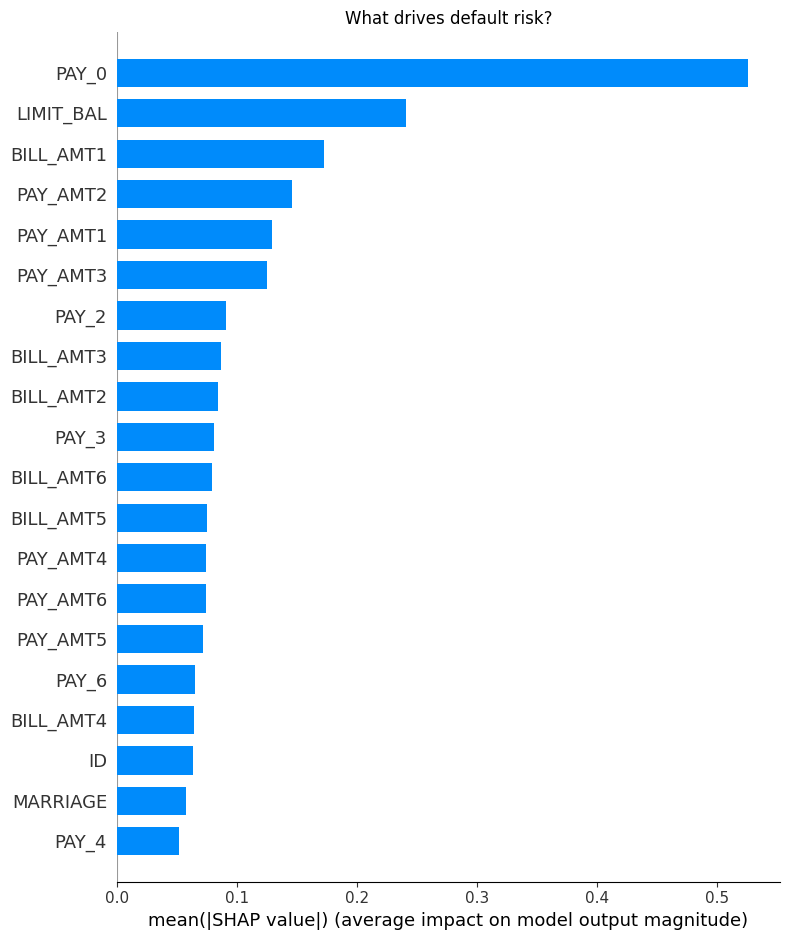

In [16]:
#Global feature Importance
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, x_test_scaled, feature_names=feature_names, plot_type='bar', show=False)
plt.title("What drives default risk?")
plt.tight_layout()
plt.show()

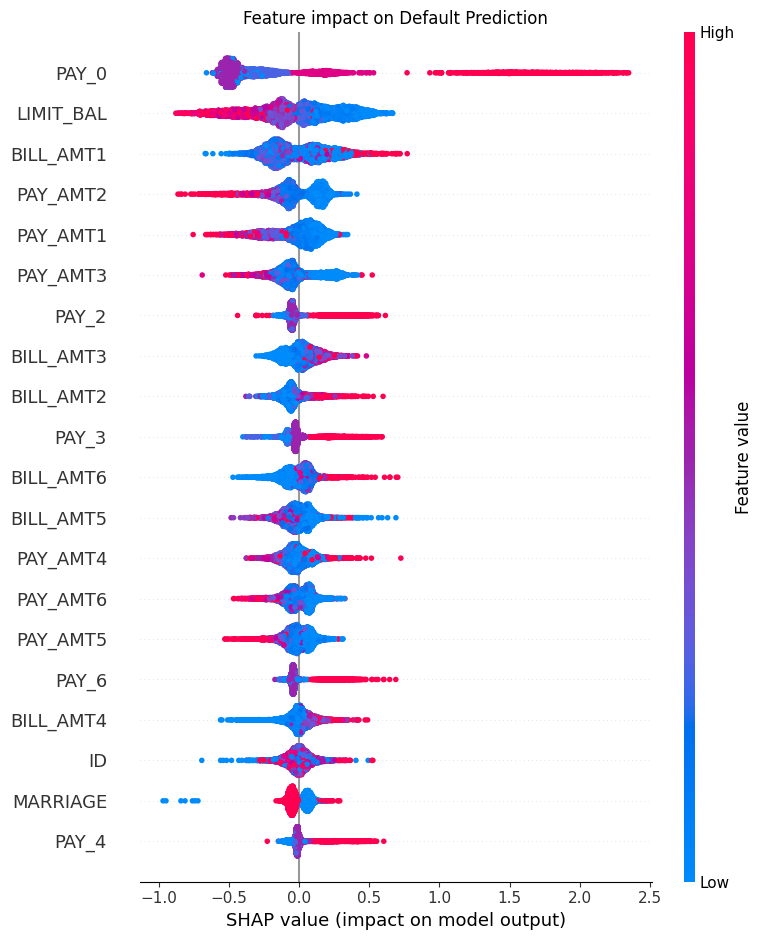

In [17]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, x_test_scaled, feature_names=feature_names, show=False)
plt.title('Feature impact on Default Prediction')
plt.tight_layout()
plt.show()

In [18]:
#Extracting important values
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(shap_values).mean(axis=0)
}).sort_values('Importance', ascending=False)

print("Top 10 features:")
print(importance_df.head(10))

Top 10 features:
      Feature  Importance
6       PAY_0    0.525833
1   LIMIT_BAL    0.240839
12  BILL_AMT1    0.172371
19   PAY_AMT2    0.145697
18   PAY_AMT1    0.129202
20   PAY_AMT3    0.125050
7       PAY_2    0.090479
14  BILL_AMT3    0.086365
13  BILL_AMT2    0.083811
8       PAY_3    0.081029


Local explanations (individual Decisions)

In [19]:
#finding examples
default_idx = np.where((y_test.values == 1) & (y_pred == 1))[0][0]
paid_idx = np.where((y_test.values == 0) &(y_pred == 0))[0][0]

Application Denied
Default Probabilty: 80.0%


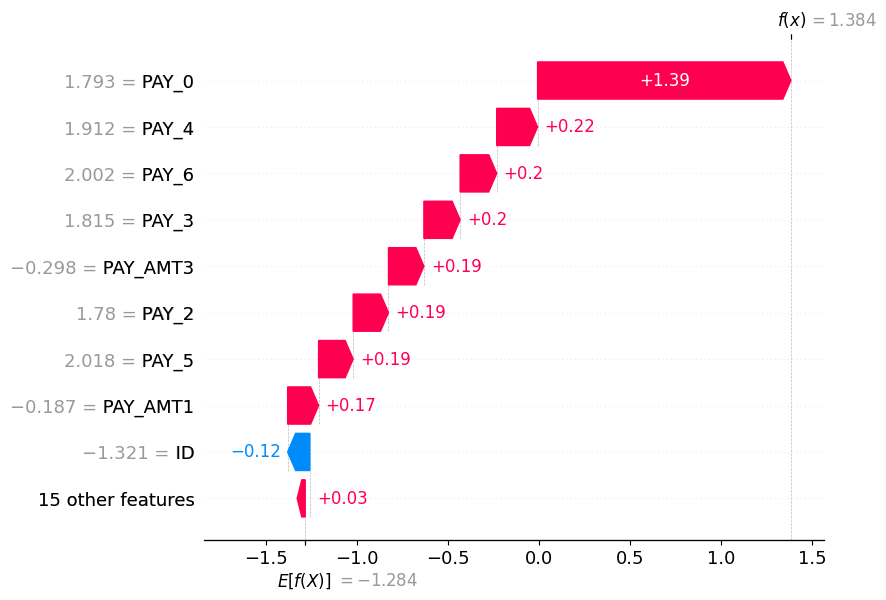

In [21]:
#Explain a denied application
print("Application Denied")
print(f"Default Probabilty: {y_prob[default_idx]:.1%}")

shap.plots.waterfall(shap.Explanation(
    values = shap_values[default_idx],
    base_values=explainer.expected_value,
    data=x_test_scaled[default_idx],
    feature_names=feature_names
), max_display=10)

Application Approved
Default Probability: 19.8%


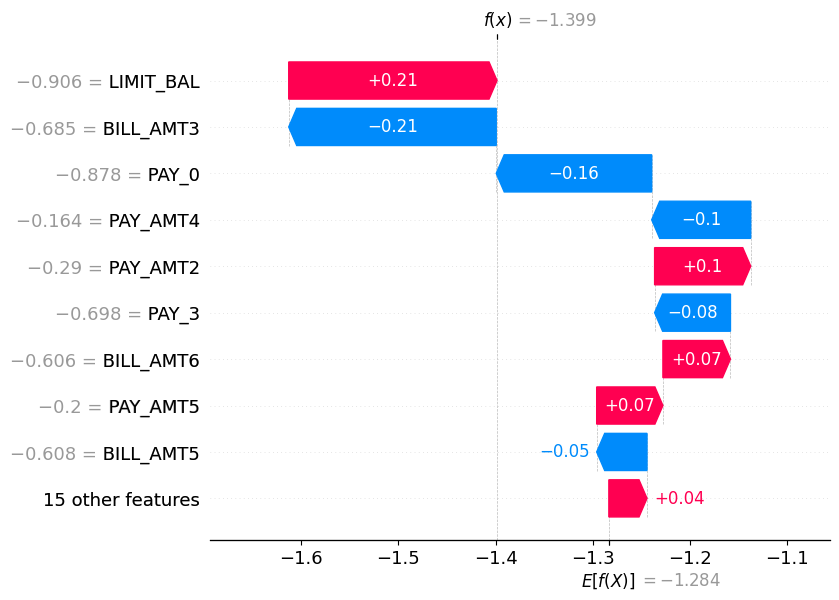

In [23]:
# Explaining an APPROVED application
print("Application Approved")
print(f"Default Probability: {y_prob[paid_idx]:.1%}")

shap.plots.waterfall(shap.Explanation(
    values=shap_values[paid_idx],
    base_values=explainer.expected_value,
    data=x_test_scaled[paid_idx],
    feature_names=feature_names
), max_display=10)

In [27]:
#legible explanation function
def explain_decision(idx):
  prob = y_prob[idx]
  decision = "DENY" if prob > 0.3 else "APPROVED"

  contributions = pd.DataFrame({
      'Feature': feature_names,
      'Impact': shap_values[idx]
  }).sort_values('Impact', key=abs, ascending=False)

  risk_factors = contributions[contributions['Impact'] > 0].head(3)
  postive_factors = contributions[contributions['Impact'] < 0].head(3)

  print(f"Application Decision: {decision}")
  print(f"Default Risk: {prob:.1%}")
  print(f"\nRisk Factors:")
  for _, row in risk_factors.iterrows():
    print(f"↑ {row['Feature']}: +{row['Impact']:.3f}")
  print(f"\nPositive Factors:")
  for _, row in postive_factors.iterrows():
    print(f"↓ {row['Feature']}: {row['Impact']:.3f}")

explain_decision(default_idx)

Application Decision: DENY
Default Risk: 80.0%

Risk Factors:
↑ PAY_0: +1.391
↑ PAY_4: +0.224
↑ PAY_6: +0.201

Positive Factors:
↓ ID: -0.122
↓ PAY_AMT4: -0.108
↓ EDUCATION: -0.100


Dependence Plota

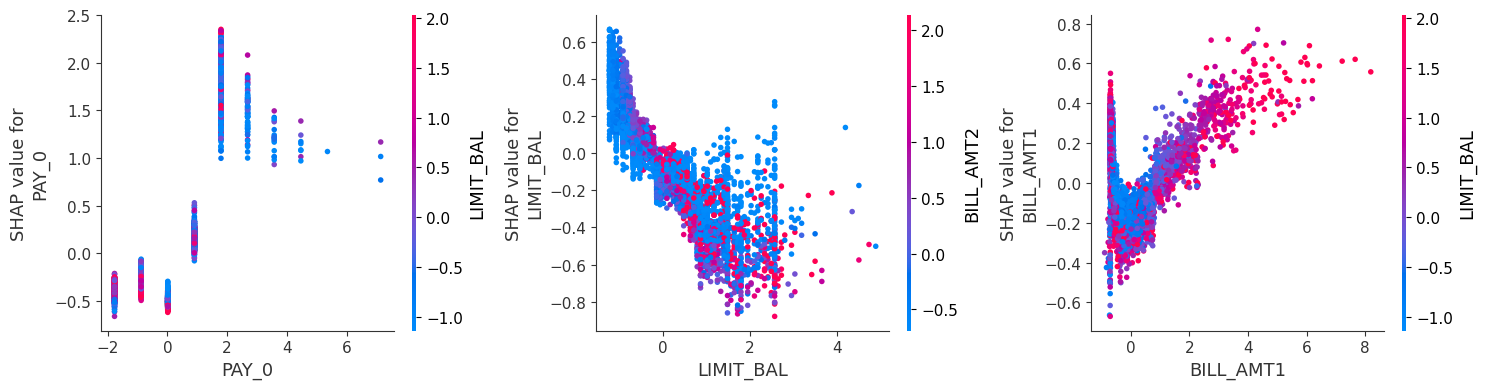

In [29]:
top_3 = importance_df.head(3)['Feature'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, feat in enumerate(top_3):
  feat_idx = feature_names.index(feat)
  shap.dependence_plot(feat_idx, shap_values, x_test_scaled,
                       feature_names=feature_names, ax=axes[i], show=False)

plt.tight_layout()
plt.show()

Production Pipeline

In [38]:
# Reload raw data
x_raw = df.drop(target_col, axis=1)
y_raw = df[target_col]

numeric_cols = x_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = x_raw.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric: {numeric_cols}")
print(f"Categorical: {categorical_cols}")

Numeric: ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Categorical: []


In [39]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

production_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=5,
        random_state=42, verbosity=0, n_jobs=-1
    ))
])

print("Pipeline created!!!")

Pipeline created!!!


In [41]:
x_train_raw, x_test_raw, y_train_raw, y_test_raw = train_test_split(
    x_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

production_pipeline.fit(x_train_raw, y_train_raw)

y_pred_pipe = production_pipeline.predict(x_test_raw)
y_prob_pipe = production_pipeline.predict_proba(x_test_raw)[:, 1]
print("Pipeline Performance:")
print(f"  Precision: {precision_score(y_test_raw, y_pred_pipe):.4f}")
print(f"  Recall:    {recall_score(y_test_raw, y_pred_pipe):.4f}")
print(f"  F1:        {f1_score(y_test_raw, y_pred_pipe):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test_raw, y_prob_pipe):.4f}")

Pipeline Performance:
  Precision: 0.3988
  Recall:    0.6775
  F1:        0.5021
  ROC-AUC:   0.7691


In [43]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search, focusing on precision
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__scale_pos_weight': [1, 3] # Experiment with lower scale_pos_weight to improve precision
}

# Initialize GridSearchCV with 'precision' as the scoring metric
grid_search = GridSearchCV(
    estimator=production_pipeline,
    param_grid=param_grid,
    scoring='precision',  # Optimize for precision
    cv=3,                 # 3-fold cross-validation
    verbose=1,
    n_jobs=-1             # Use all available cores
)

print("Starting GridSearchCV to tune hyperparameters...")
# Fit GridSearchCV
grid_search.fit(x_train_raw, y_train_raw)

# Print the best parameters and best score
print("\nBest parameters found: ", grid_search.best_params_)
print("Best cross-validation precision score found: ", grid_search.best_score_)

# Get the best estimator (tuned pipeline)
tuned_pipeline = grid_search.best_estimator_

# Evaluate the tuned pipeline on the test set
y_pred_tuned = tuned_pipeline.predict(x_test_raw)
y_prob_tuned = tuned_pipeline.predict_proba(x_test_raw)[:, 1]

print("\nTuned Pipeline Performance on Test Set:")
print(f"  Precision: {precision_score(y_test_raw, y_pred_tuned):.4f}")
print(f"  Recall:    {recall_score(y_test_raw, y_pred_tuned):.4f}")
print(f"  F1:        {f1_score(y_test_raw, y_pred_tuned):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test_raw, y_prob_tuned):.4f}")

Starting GridSearchCV to tune hyperparameters...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best parameters found:  {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__scale_pos_weight': 1}
Best cross-validation precision score found:  0.6864037223910886

Tuned Pipeline Performance on Test Set:
  Precision: 0.6676
  Recall:    0.3527
  F1:        0.4615
  ROC-AUC:   0.7753


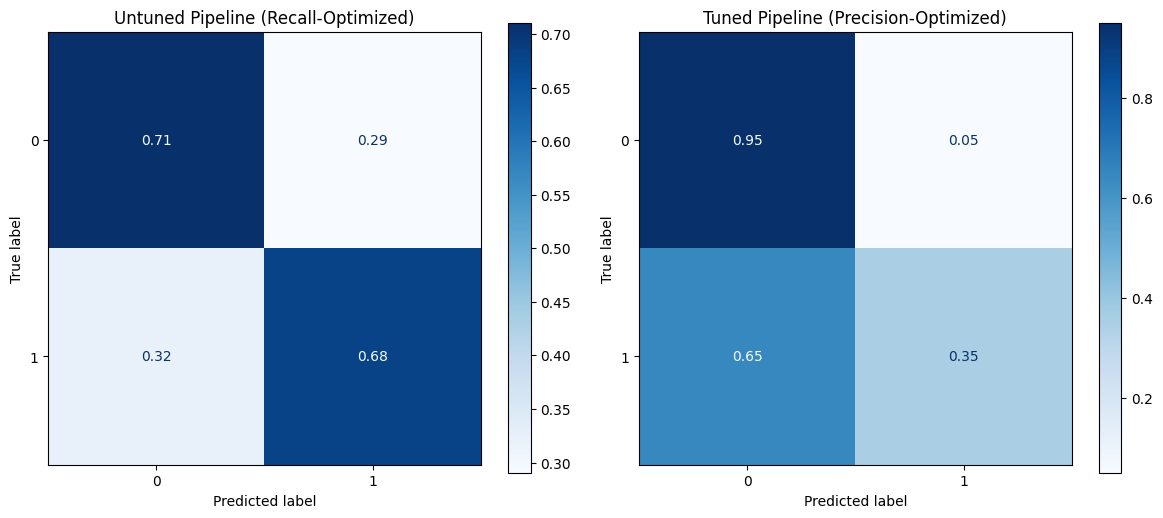

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes  = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix for the untuned pipeline
ConfusionMatrixDisplay.from_estimator(production_pipeline, x_test_raw, y_test_raw, ax=axes[0], cmap='Blues', normalize='true')
axes[0].set_title('Untuned Pipeline (Recall-Optimized)')

# Confusion Matrix for the tuned pipeline (Precision-Optimized)
ConfusionMatrixDisplay.from_estimator(tuned_pipeline, x_test_raw, y_test_raw, ax=axes[1], cmap='Blues', normalize='true')
axes[1].set_title('Tuned Pipeline (Precision-Optimized)')

plt.tight_layout()
plt.show()

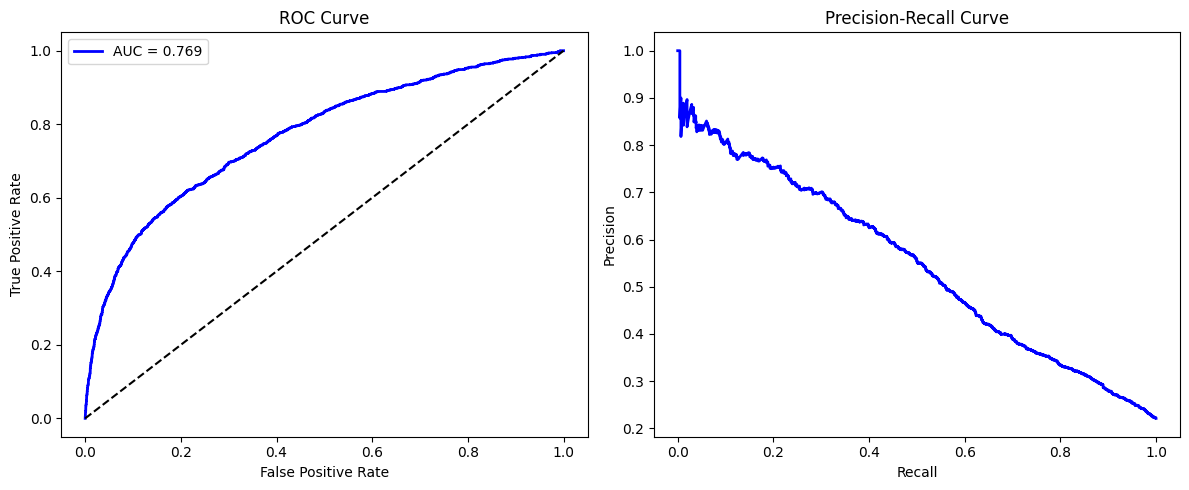

In [45]:
# ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test_raw, y_prob_pipe)
axes[0].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {roc_auc_score(y_test_raw, y_prob_pipe):.3f}')
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Precision-Recall
prec, rec, _ = precision_recall_curve(y_test_raw, y_prob_pipe)
axes[1].plot(rec, prec, 'b-', linewidth=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

Prediction API

In [49]:
def predict_loan(application, pipeline, threshold=0.3):
  """

  Predict loan default risk.

  Returns: decisions, probability, risk level
  """
  if isinstance(application, dict):
    application = pd.DataFrame([application])

  prob = pipeline.predict_proba(application)[0, 1]

  if prob >= 0.5:
    return {'decision': "DENY", 'probability': f'{prob:.1%}', 'risk': 'HIGH'}
  elif prob >= threshold:
    return {'decision': "REVIEW", 'probability': f'{prob:.1%}', 'risk': 'MEDIUM'}
  else:
    return {'decision': "APPROVE", 'probability': f'{prob:.1%}', 'risk': 'LOW'}

#Test
sample = x_test_raw.iloc[[0]]
result = predict_loan(sample, production_pipeline)
print("Sample prediction:")
print(result)

Sample prediction:
{'decision': 'REVIEW', 'probability': '44.9%', 'risk': 'MEDIUM'}


In [54]:
# Batch predictions
def batch_predict(applications, pipeline, threshold=0.3):
    probs = pipeline.predict_proba(applications)[:, 1]

    results = pd.DataFrame({
        'probability': probs,
        'risk': pd.cut(probs, bins=[0, threshold, 0.5, 1], labels=['LOW', 'MEDIUM', 'HIGH']),
        'decision': np.where(probs >= 0.5, 'DENY', np.where(probs >= threshold, 'REVIEW', 'APPROVE'))
    })

    return results

# Test batch
batch_results = batch_predict(x_test_raw.head(10), production_pipeline)
print("Batch predictions:")
print(batch_results)

Batch predictions:
   probability    risk decision
0     0.448913  MEDIUM   REVIEW
1     0.416678  MEDIUM   REVIEW
2     0.554030    HIGH     DENY
3     0.331874  MEDIUM   REVIEW
4     0.055403     LOW  APPROVE
5     0.393469  MEDIUM   REVIEW
6     0.377831  MEDIUM   REVIEW
7     0.039865     LOW  APPROVE
8     0.397027  MEDIUM   REVIEW
9     0.199468     LOW  APPROVE


In [55]:
# Save everything
artifacts = {
    'pipeline': production_pipeline,
    'threshold': 0.3,
    'feature_names': numeric_cols + categorical_cols,
    'metrics': {
        'precision': precision_score(y_test_raw, y_pred_pipe),
        'recall': recall_score(y_test_raw, y_pred_pipe),
        'f1': f1_score(y_test_raw, y_pred_pipe),
        'roc_auc': roc_auc_score(y_test_raw, y_prob_pipe)
    },
    'version': '1.0'
}

joblib.dump(artifacts, 'loan_default_model.joblib')
print("Model saved to 'loan_default_model.joblib'")

Model saved to 'loan_default_model.joblib'


In [56]:
# Verify loading
loaded = joblib.load('loan_default_model.joblib')
print("Loaded successfully!")
print(f"Version: {loaded['version']}")
print(f"Metrics: {loaded['metrics']}")

Loaded successfully!
Version: 1.0
Metrics: {'precision': 0.39884649511978704, 'recall': 0.6774679728711379, 'f1': 0.5020943870427255, 'roc_auc': np.float64(0.7690961770958598)}
